In [153]:
import pandas as pd

# AAP daily OHLCV; path is relative to this notebook's working directory
csv_path = "./individual_stocks_5yr/AAP_data.csv"
df = pd.read_csv(csv_path, parse_dates=["date"])

# Quick sanity check: shape, dtypes, first rows
print(df.shape)
print(df.dtypes)
df.head()

(1259, 7)
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name              object
dtype: object


,date,open,high,low,close,volume,Name
0,2013-02-08,78.34,79.72,78.0100,78.90,1298137,AAP
1,2013-02-11,78.65,78.91,77.2300,78.39,758016,AAP
2,2013-02-12,78.39,78.63,77.5132,78.60,876859,AAP
3,2013-02-13,78.90,79.13,77.8500,78.97,1038574,AAP
4,2013-02-14,78.66,79.72,78.5850,78.84,1005376,AAP


In [154]:
# Null/NaN vs empty strings are separate: "" is not NaN in object columns
null_per_col = df.isna().sum()
print("Null / NaN count per column:")
print(null_per_col.to_string())

cols_with_nulls = null_per_col[null_per_col > 0]
print()
if len(cols_with_nulls):
    print("Columns with at least one missing value:")
    print(cols_with_nulls.to_string())
else:
    print("No null or NaN in any column (all counts are 0).")

# Empty = whitespace-stripped string length 0 (skip numeric/datetime dtypes)
def _n_empty_strings(col):
    if pd.api.types.is_numeric_dtype(col) or pd.api.types.is_datetime64_any_dtype(col):
        return 0
    return col.astype(str).str.strip().eq("").sum()

empty_per_col = df.apply(_n_empty_strings)
print()
print("Empty string count per column (after strip):")
print(empty_per_col.to_string())

cols_with_empty = empty_per_col[empty_per_col > 0]
print()
if len(cols_with_empty):
    print("Columns with at least one empty string:")
    print(cols_with_empty.to_string())
else:
    print("No empty strings in scanned text columns (all counts are 0).")

Null / NaN count per column:
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No null or NaN in any column (all counts are 0).

Empty string count per column (after strip):
date      0
open      0
high      0
low       0
close     0
volume    0
Name      0

No empty strings in scanned text columns (all counts are 0).


In [155]:
import numpy as np
import pandas as pd

from sklearn.linear_model import HuberRegressor, LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import (
    balanced_accuracy_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    accuracy_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler

# Target is next-day simple return (e.g. 0.006 = 0.6%). If R² is flat, that is normal for daily returns;
# I also fit logistic regression on "next day up vs not" (accuracy / ROC-AUC) and add realized volatility as a feature.
# Features are scale-free (% moves, ratios, vol). Robust-scale on train only. Ridge CV on train — no peek at test.

# Ridge L2 strengths to search; RidgeCV picks one and refits on all training rows.
ridge_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 5, 10, 12, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 500, 1000, 2000, 3000, 4000, 5000, 10000, 20000]
# Past rows train, future chunk validates — keeps calendar order (not shuffled K-fold).
ridge_cv_splitter = TimeSeriesSplit(n_splits=5)

df_multi = df.copy()
df_multi["return_next"] = (
    (df_multi["close"].shift(-1) - df_multi["close"]) / df_multi["close"]
)
# --- Features as percentages / ratios (scale-free) ---
df_multi["daily_return"] = df_multi["close"].pct_change()
# Classic H-L range as % of close (kept for EDA / optional plots).
df_multi["range_pct"] = (df_multi["high"] - df_multi["low"]) / df_multi["close"]
# True range: max(H-L, |H-prev_close|, |L-prev_close|) / close — captures overnight gaps, not only the session bar.
_prev_close = df_multi["close"].shift(1)
_true_range = pd.concat(
    [
        df_multi["high"] - df_multi["low"],
        (df_multi["high"] - _prev_close).abs(),
        (df_multi["low"] - _prev_close).abs(),
    ],
    axis=1,
).max(axis=1)
df_multi["true_range_pct"] = _true_range / df_multi["close"]

df_multi["intraday_return"] = (df_multi["close"] - df_multi["open"]) / df_multi["open"]
df_multi["gap_pct"] = (df_multi["open"] - df_multi["close"].shift(1)) / df_multi["close"].shift(1)
df_multi["log_volume"] = np.log1p(df_multi["volume"])
# Today's volume vs trailing average (dimensionless): "relative volume" / RVOL style, more stationary than raw log size.
df_multi["relative_volume_20d"] = df_multi["volume"] / df_multi["volume"].rolling(
    20, min_periods=20
).mean()

# 1-day momentum (for correlation EDA only)
df_multi["prev_return"] = df_multi["daily_return"].shift(1)

# Past 5-day realized vol (std of daily returns): regime / risk proxy; uses only past days at each row.
df_multi["realized_volatility_5d"] = df_multi["daily_return"].rolling(window=5, min_periods=5).std()

# Volatility alias for correlation EDA (same series)
df_multi["volatility_5d"] = df_multi["realized_volatility_5d"]

# Volume Trend (for correlation EDA only)
df_multi["volume_momentum"] = df_multi["log_volume"] / df_multi["log_volume"].rolling(5).mean()

# Model inputs: true_range_pct + relative_volume_20d replace plain range_pct + log_volume (often better behaved).
feature_names = [
    "daily_return",
    "true_range_pct",
    "intraday_return",
    "gap_pct",
    "relative_volume_20d",
    "realized_volatility_5d",
]

# Need prior close (gap, true range), 5d vol, 20d volume window — dropna enforces valid rows.
df_multi = df_multi.dropna(
    subset=[
        "return_next",
        "daily_return",
        "gap_pct",
        "realized_volatility_5d",
        "true_range_pct",
        "relative_volume_20d",
    ]
)

correlation_columns = feature_names + ["return_next"]
correlation_matrix = df_multi[correlation_columns].corr()

features_raw = df_multi[feature_names].to_numpy()
target_next_day_return = df_multi["return_next"].to_numpy().reshape(-1, 1)
# Binary label for logistic regression: next day up (1) vs down or flat (0). Same rows as regression target.
target_next_day_up = (df_multi["return_next"] > 0).astype(np.int8).to_numpy().reshape(-1, 1)
dates_all = pd.to_datetime(df_multi["date"])

# Last 20% of rows = test; I don't shuffle so I'm not mixing future and past.
(
    features_train_raw,
    features_test_raw,
    target_train,
    target_test,
    target_train_direction,
    target_test_direction,
    dates_train,
    dates_test,
) = train_test_split(
    features_raw,
    target_next_day_return,
    target_next_day_up,
    dates_all,
    test_size=0.2,
    shuffle=False,
)

# Winsorize next-day return: cap train labels at train quantiles, reuse the same bounds on test.
# (Correlation matrix still uses raw return_next in df_multi; only the regression targets below are clipped.)
TARGET_WINSOR_PERCENTILES = (1.0, 99.0)
target_winsor_lower, target_winsor_upper = np.nanpercentile(
    target_train, TARGET_WINSOR_PERCENTILES
)
target_train = np.clip(target_train, target_winsor_lower, target_winsor_upper)
target_test = np.clip(target_test, target_winsor_lower, target_winsor_upper)
print(
    f"Target winsorized at train percentiles {TARGET_WINSOR_PERCENTILES[0]:.1f}% / "
    f"{TARGET_WINSOR_PERCENTILES[1]:.1f}% → clip to [{target_winsor_lower:.6f}, {target_winsor_upper:.6f}] "
    "(decimal return)"
)

# RobustScaler: median and IQR from train; same transform on test (no leakage).
robust_feature_scaler = RobustScaler()
features_train = robust_feature_scaler.fit_transform(features_train_raw)
features_test = robust_feature_scaler.transform(features_test_raw)

# Mean CV RMSE for each Ridge alpha (same splitter as RidgeCV) — used in the alpha curve plot.
ridge_cv_rmse_by_alpha = []
for ridge_alpha in ridge_alphas:
    neg_mse_scores = cross_val_score(
        Ridge(alpha=ridge_alpha, fit_intercept=True),
        features_train,
        target_train.ravel(),
        cv=ridge_cv_splitter,
        scoring="neg_mean_squared_error",
    )
    mse_mean = -neg_mse_scores.mean()
    ridge_cv_rmse_by_alpha.append(np.sqrt(mse_mean))

ridge_cv = RidgeCV(alphas=ridge_alphas, cv=ridge_cv_splitter, fit_intercept=True)
ridge_cv.fit(features_train, target_train.ravel())

predictions_train = ridge_cv.predict(features_train).reshape(-1, 1)
predictions_test = ridge_cv.predict(features_test).reshape(-1, 1)

r2_train = r2_score(target_train, predictions_train)
r2_test = r2_score(target_test, predictions_test)
rmse_train = float(np.sqrt(mean_squared_error(target_train, predictions_train)))
rmse_test = float(np.sqrt(mean_squared_error(target_test, predictions_test)))

residuals_test = (target_test - predictions_test).ravel()

# HuberRegressor as a robust baseline; same alpha as Ridge for a rough comparison.
huber_regressor = HuberRegressor(max_iter=200, alpha=ridge_cv.alpha_)
huber_regressor.fit(features_train, target_train.ravel())
predictions_test_huber = huber_regressor.predict(features_test).reshape(-1, 1)
rmse_test_huber = float(np.sqrt(mean_squared_error(target_test, predictions_test_huber)))

# --- Logistic regression: predict P(next day up) — a different question than continuous return (R² can be ~0
# while direction still carries a weak signal). Same scaled features; class_weight balances up/down if skewed.
logistic_regression = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
)
logistic_regression.fit(features_train, target_train_direction.ravel())
logistic_predictions_test = logistic_regression.predict(features_test)
logistic_proba_test = logistic_regression.predict_proba(features_test)[:, 1]
logistic_accuracy_test = float(accuracy_score(target_test_direction, logistic_predictions_test))
logistic_balanced_accuracy_test = float(
    balanced_accuracy_score(target_test_direction, logistic_predictions_test)
)
if len(np.unique(target_test_direction)) < 2:
    logistic_roc_auc_test = float("nan")
else:
    logistic_roc_auc_test = float(roc_auc_score(target_test_direction.ravel(), logistic_proba_test))
logistic_cv_roc_auc_mean = float(
    np.mean(
        cross_val_score(
            LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs"),
            features_train,
            target_train_direction.ravel(),
            cv=ridge_cv_splitter,
            scoring="roc_auc",
        )
    )
)


Target winsorized at train percentiles 1.0% / 99.0% → clip to [-0.037226, 0.040210] (decimal return)


In [156]:
# Closed-form check: same solution as sklearn.Ridge(fit_intercept=True) on robust-scaled features.

ridge_alpha = float(ridge_cv.alpha_)
X_train_scaled = np.asarray(features_train, dtype=float)
target_train_1d = target_train.ravel().astype(float)

feature_means_train = X_train_scaled.mean(axis=0)
target_mean_train = float(target_train_1d.mean())
X_centered = X_train_scaled - feature_means_train
target_centered = target_train_1d - target_mean_train
n_features = X_train_scaled.shape[1]
gram_matrix = X_centered.T @ X_centered + ridge_alpha * np.eye(n_features)
normal_eq_rhs = X_centered.T @ target_centered
try:
    coefficients_numpy = np.linalg.solve(gram_matrix, normal_eq_rhs)
except np.linalg.LinAlgError:
    coefficients_numpy = np.linalg.pinv(gram_matrix) @ normal_eq_rhs

intercept_numpy = target_mean_train - float(feature_means_train @ coefficients_numpy)

coefficients_sklearn = np.asarray(ridge_cv.coef_).ravel()
intercept_sklearn = float(ridge_cv.intercept_)

print("NumPy vs sklearn Ridge (same alpha, RobustScaler on train features)")
print(
    f"  max |coef difference|: {np.max(np.abs(coefficients_numpy - coefficients_sklearn)):.2e}"
)
print(f"  |intercept difference|: {abs(intercept_numpy - intercept_sklearn):.2e}")
np.testing.assert_allclose(coefficients_numpy, coefficients_sklearn, rtol=1e-5, atol=1e-6)
np.testing.assert_allclose(intercept_numpy, intercept_sklearn, rtol=1e-5, atol=1e-6)
print("  OK: matches Ridge/RidgeCV refit.")


NumPy vs sklearn Ridge (same alpha, RobustScaler on train features)
  max |coef difference|: 6.78e-21
  |intercept difference|: 0.00e+00
  OK: matches Ridge/RidgeCV refit.


Correlation matrix (rounded):
                        daily_return  true_range_pct  intraday_return  \
daily_return                   1.000           0.006            0.747   
true_range_pct                 0.006           1.000            0.004   
intraday_return                0.747           0.004            1.000   
gap_pct                        0.681          -0.008            0.023   
relative_volume_20d            0.014           0.665            0.033   
realized_volatility_5d         0.062           0.473            0.025   
return_next                   -0.019          -0.004            0.006   

                        gap_pct  relative_volume_20d  realized_volatility_5d  \
daily_return              0.681                0.014                   0.062   
true_range_pct           -0.008                0.665                   0.473   
intraday_return           0.023                0.033                   0.025   
gap_pct                   1.000               -0.022             

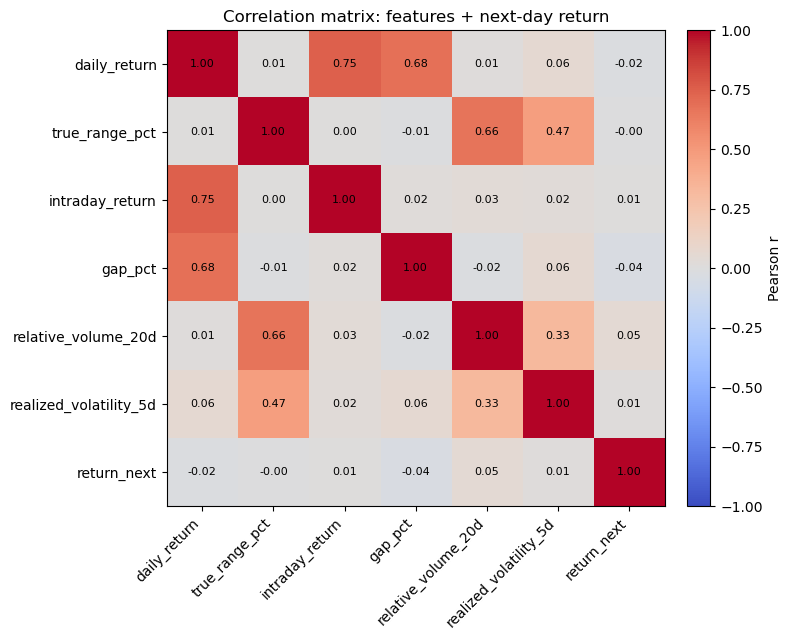

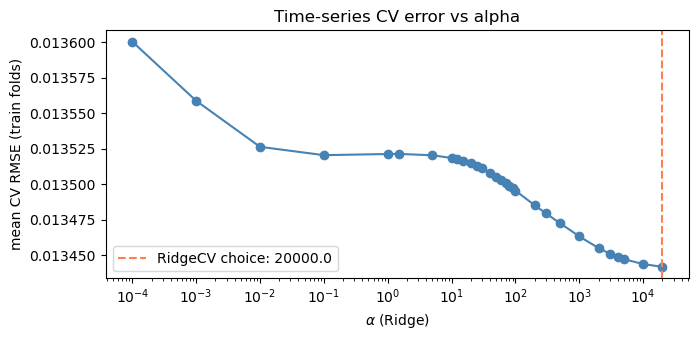

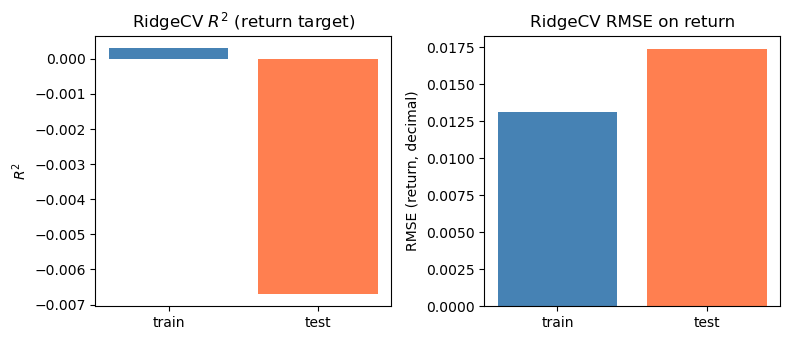

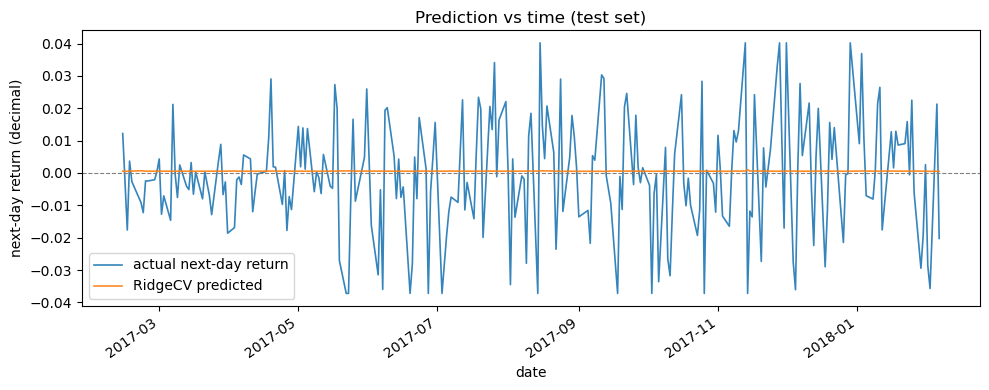

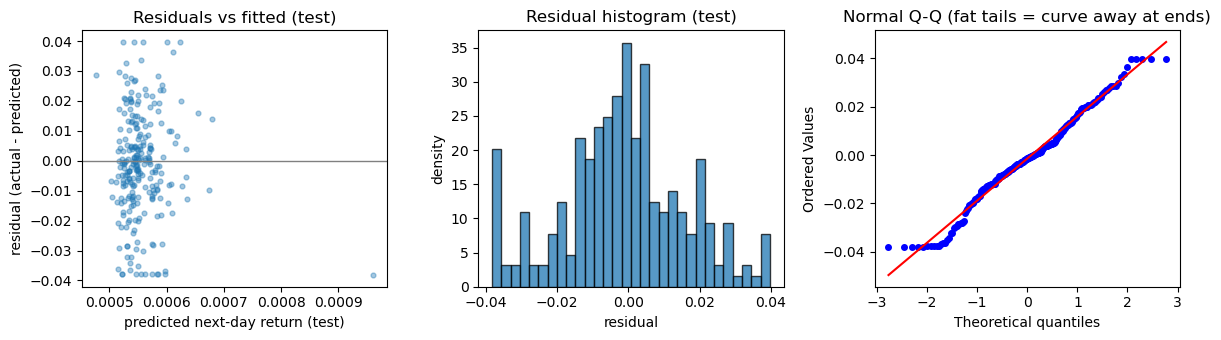

In [157]:
import matplotlib.pyplot as plt
import scipy.stats as st

# --- Uses setup: correlation_matrix, ridge_cv, predictions_*, etc. ---
# Quick pairwise view (linear relationships only — my model is linear too).

print("Correlation matrix (rounded):")
print(correlation_matrix.round(3))

fig_corr, ax_corr = plt.subplots(figsize=(8, 6.5))
heatmap = ax_corr.imshow(
    correlation_matrix.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)
ax_corr.set_xticks(range(len(correlation_matrix.columns)))
ax_corr.set_yticks(range(len(correlation_matrix.columns)))
ax_corr.set_xticklabels(correlation_matrix.columns, rotation=45, ha="right")
ax_corr.set_yticklabels(correlation_matrix.columns)
for row_idx in range(len(correlation_matrix)):
    for col_idx in range(len(correlation_matrix)):
        ax_corr.text(
            col_idx,
            row_idx,
            f"{correlation_matrix.values[row_idx, col_idx]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
fig_corr.colorbar(heatmap, ax=ax_corr, fraction=0.046, pad=0.04, label="Pearson r")
ax_corr.set_title("Correlation matrix: features + next-day return")
plt.tight_layout()
plt.show()

# How CV error moves as I turn regularization up (bigger alpha = simpler model).
fig_alpha, ax_alpha = plt.subplots(figsize=(7, 3.5))
ax_alpha.semilogx(ridge_alphas, ridge_cv_rmse_by_alpha, "o-", color="steelblue")
ax_alpha.axvline(ridge_cv.alpha_, color="coral", ls="--", label=f"RidgeCV choice: {ridge_cv.alpha_}")
ax_alpha.set_xlabel(r"$\alpha$ (Ridge)")
ax_alpha.set_ylabel("mean CV RMSE (train folds)")
ax_alpha.set_title("Time-series CV error vs alpha")
ax_alpha.legend()
plt.tight_layout()
plt.show()

# Train vs test — if test is way worse, I'm probably not generalizing to the later period.
fig_metrics, axes_metrics = plt.subplots(1, 2, figsize=(8, 3.5))
axes_metrics[0].bar(["train", "test"], [r2_train, r2_test], color=["steelblue", "coral"])
axes_metrics[0].set_ylabel(r"$R^2$")
axes_metrics[0].set_title(r"RidgeCV $R^2$ (return target)")
axes_metrics[1].bar(["train", "test"], [rmse_train, rmse_test], color=["steelblue", "coral"])
axes_metrics[1].set_ylabel("RMSE (return, decimal)")
axes_metrics[1].set_title("RidgeCV RMSE on return")
plt.tight_layout()
plt.show()

fig_time, ax_time = plt.subplots(figsize=(10, 4))
ax_time.plot(dates_test, target_test.ravel(), label="actual next-day return", lw=1.2, alpha=0.9)
ax_time.plot(
    dates_test,
    predictions_test.ravel(),
    label="RidgeCV predicted",
    lw=1.2,
    alpha=0.9,
)
ax_time.axhline(0.0, color="gray", lw=0.8, ls="--")
ax_time.set_xlabel("date")
ax_time.set_ylabel("next-day return (decimal)")
ax_time.set_title("Prediction vs time (test set)")
ax_time.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Residuals: random cloud vs fan shape; tails on the Q-Q vs a straight line.
fig_resid, axes_resid = plt.subplots(1, 3, figsize=(12, 3.5))
axes_resid[0].scatter(predictions_test.ravel(), residuals_test, s=12, alpha=0.4)
axes_resid[0].axhline(0.0, color="gray", lw=1)
axes_resid[0].set_xlabel("predicted next-day return (test)")
axes_resid[0].set_ylabel("residual (actual - predicted)")
axes_resid[0].set_title("Residuals vs fitted (test)")
axes_resid[1].hist(residuals_test, bins=30, edgecolor="black", alpha=0.75, density=True)
axes_resid[1].set_xlabel("residual")
axes_resid[1].set_ylabel("density")
axes_resid[1].set_title("Residual histogram (test)")
st.probplot(residuals_test, dist="norm", plot=axes_resid[2])
axes_resid[2].set_title("Normal Q-Q (fat tails = curve away at ends)")
axes_resid[2].get_lines()[0].set_markersize(4)
plt.tight_layout()
plt.show()


In [159]:
import numpy as np
import scipy.stats as st

# --- After plots: numbers I report (uses cells above) ---
# Skew / kurtosis — returns rarely look perfectly Gaussian.

test_residual_skewness = float(st.skew(residuals_test))
test_residual_excess_kurtosis = float(st.kurtosis(residuals_test, fisher=True))
# Rough outlier rate vs Gaussian tails (~0.3% beyond |3σ| if normal).
test_residual_z_scores = (residuals_test - residuals_test.mean()) / residuals_test.std(ddof=0)
fraction_test_residuals_abs_z_above_3 = float(np.mean(np.abs(test_residual_z_scores) > 3))

print(f"Test residual skew: {test_residual_skewness:.4f}  (0 if symmetric)")
print(
    f"Test residual excess kurtosis: {test_residual_excess_kurtosis:.4f}  "
    f"(0 for Gaussian; >0 => heavier tails)"
)
print(
    f"Fraction |standardized residual| > 3: {fraction_test_residuals_abs_z_above_3:.4f}  (~0.003 if Gaussian)"
)
print(
    f"Huber test RMSE: {rmse_test_huber:.6f}  vs Ridge test RMSE: {rmse_test:.6f}"
)

print(
    "Logistic regression (next day up vs not): "
    f"test accuracy={logistic_accuracy_test:.4f}, balanced accuracy={logistic_balanced_accuracy_test:.4f}, "
    f"ROC-AUC={logistic_roc_auc_test:.4f} (0.5 = random; mean time-series CV ROC-AUC on train folds={logistic_cv_roc_auc_mean:.4f})"
)

print(f"Ridge alphas tried: {ridge_alphas}")
print(f"RidgeCV selected alpha: {ridge_cv.alpha_}")
print(f"intercept: {ridge_cv.intercept_:.6f}")
for name, coef in zip(feature_names, ridge_cv.coef_):
    print(f"  coef[{name}]: {coef:.6f}  (RobustScaler: median/IQR on train)")
print(f"R^2 train: {r2_train:.6f}  |  R^2 test: {r2_test:.6f}")
print(
    f"RMSE train: {rmse_train:.6f}  |  RMSE test: {rmse_test:.6f}  (return decimal; *100 for %)"
)


Test residual skew: -0.0409  (0 if symmetric)
Test residual excess kurtosis: -0.0807  (0 for Gaussian; >0 => heavier tails)
Fraction |standardized residual| > 3: 0.0000  (~0.003 if Gaussian)
Huber test RMSE: 0.017447  vs Ridge test RMSE: 0.017419
Logistic regression (next day up vs not): test accuracy=0.4919, balanced accuracy=0.4821, ROC-AUC=0.4568 (0.5 = random; mean time-series CV ROC-AUC on train folds=0.4972)
Ridge alphas tried: [0.0001, 0.001, 0.01, 0.1, 1, 1.5, 5, 10, 12, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 500, 1000, 2000, 3000, 4000, 5000, 10000, 20000]
RidgeCV selected alpha: 20000.0
intercept: 0.000547
  coef[daily_return]: 0.000002  (RobustScaler: median/IQR on train)
  coef[true_range_pct]: -0.000006  (RobustScaler: median/IQR on train)
  coef[intraday_return]: -0.000001  (RobustScaler: median/IQR on train)
  coef[gap_pct]: 0.000009  (RobustScaler: median/IQR on train)
  coef[relative_volume_20d]: 0.000033  (RobustScaler: median/IQR on train)
  coef[real